# FHWA Corridor and Traffic Demand

## Goal

Download official FHWA Highway Performance Monitoring System (HPMS) road segments for the seven-county study area and create a preliminary DC-fast corridor-demand score using AADT, interstate proximity, and existing charging gaps.

FHWA HPMS overview: https://www.fhwa.dot.gov/policyinformation/hpms.cfm

FHWA public geospatial release documentation: https://www.fhwa.dot.gov/policyinformation/hpms/shapefiles.cfm

## Context & Methods

The original workflow targeted Georgia DOT's public ArcGIS service, but that host was unreachable during execution. This reproducible fallback uses FHWA's queryable Georgia 2018 HPMS public-release service. HPMS contains segment-level AADT, functional class, and route-signing attributes submitted by state DOTs and reviewed by FHWA.

The corridor model is intentionally separate from community Level 2 charging. It rewards proximity to interstate travel, high nearby AADT, and an existing DC-fast charging gap.

### Key assumptions

- AADT represents annual average daily traffic on a road segment, not EV traffic.
- The 2018 HPMS vintage is suitable for preliminary regional screening but must be refreshed before investment decisions.
- The nearest road segment to a block-group representative point is a screening proxy.
- Interstate geometry is identified with HPMS functional-system code 1; U.S. highways use route-signing code 3.
- Corridor scores rank block groups for follow-up; they do not identify buildable parcels or utility capacity.

In [1]:
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability")
ROAD_DIR = PROJECT_ROOT / "data" / "raw" / "roads"
TRAFFIC_DIR = PROJECT_ROOT / "data" / "raw" / "traffic"
SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
MAP_DIR = PROJECT_ROOT / "maps"
for folder in [ROAD_DIR, TRAFFIC_DIR, SPATIAL_DIR, TABLE_DIR, MAP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SERVICE_ROOT = "https://geo.dot.gov/server/rest/services/Hosted/Georgia_2018_PR/FeatureServer/0"
STUDY_COUNTY_CODES = (13, 59, 135, 139, 157, 219, 297)
study_area_path = SPATIAL_DIR / "study_area_counties.gpkg"
gap_path = SPATIAL_DIR / "charging_gap_block_groups.gpkg"
if not study_area_path.exists() or not gap_path.exists():
    raise FileNotFoundError("Run notebooks 03 and 05 before the GDOT corridor analysis.")

study_area = gpd.read_file(study_area_path, layer="study_counties").to_crs("EPSG:4326")
gap = gpd.read_file(gap_path, layer="charging_gaps").to_crs("EPSG:4326")
print("Study counties:", len(study_area))
print("Gap-analysis block groups:", len(gap))

Study counties: 7
Gap-analysis block groups: 926


## Data

### 1. Download official FHWA HPMS segments

The query is filtered to the seven study counties before download. The returned road segments are cached as a local GeoPackage along with the service metadata.

In [2]:
def read_json(url, parameters):
    request = Request(
        f"{url}?{urlencode(parameters)}",
        headers={"User-Agent": "GIS-Portfolio-EV-Suitability/1.0"},
    )
    with urlopen(request, timeout=180) as response:
        return json.load(response)


def download_hpms_segments(page_size=2000):
    metadata = read_json(SERVICE_ROOT, {"f": "json"})
    county_filter = "county_code in (" + ",".join(map(str, STUDY_COUNTY_CODES)) + ")"
    features = []
    offset = 0
    while True:
        page = read_json(
            f"{SERVICE_ROOT}/query",
            {
                "where": county_filter,
                "outFields": "*",
                "returnGeometry": "true",
                "outSR": "4326",
                "f": "geojson",
                "resultOffset": offset,
                "resultRecordCount": page_size,
                "orderByFields": "objectid",
            },
        )
        page_features = page.get("features", [])
        features.extend(page_features)
        if len(page_features) < page_size:
            break
        offset += page_size
    return gpd.GeoDataFrame.from_features(features, crs="EPSG:4326"), metadata


hpms, metadata = download_hpms_segments()
hpms.columns = [column.lower() for column in hpms.columns]
metadata_path = TRAFFIC_DIR / "fhwa_hpms_georgia_2018_service_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

hpms["aadt_value"] = pd.to_numeric(hpms["aadt"], errors="coerce")
aadt = hpms.loc[hpms["aadt_value"] > 0].copy()
interstates = hpms.loc[pd.to_numeric(hpms["f_system"], errors="coerce") == 1].copy()
us_highways = hpms.loc[pd.to_numeric(hpms["route_signing"], errors="coerce") == 3].copy()

aadt.to_file(TRAFFIC_DIR / "fhwa_hpms_aadt_study_area.gpkg", layer="aadt", driver="GPKG")
interstates.to_file(ROAD_DIR / "fhwa_hpms_interstates_study_area.gpkg", layer="interstates", driver="GPKG")
us_highways.to_file(ROAD_DIR / "fhwa_hpms_us_highways_study_area.gpkg", layer="us_highways", driver="GPKG")

print(f"HPMS segments: {len(hpms):,}")
print(f"Positive-AADT segments: {len(aadt):,}")
print(f"Interstate segments: {len(interstates):,}")
print(f"U.S. highway segments: {len(us_highways):,}")

HPMS segments: 13,521
Positive-AADT segments: 13,520
Interstate segments: 995
U.S. highway segments: 3,202


### 2. Validate traffic volume and route classifications

In [3]:
valid_aadt = aadt.copy()
AADT_FIELD = "aadt"

assert not valid_aadt.empty, "No positive AADT values were found."
assert not interstates.empty, "No HPMS interstate segments were found."
assert not us_highways.empty, "No HPMS U.S. highway segments were found."
assert set(hpms["county_code"].dropna().astype(int).unique()).issubset(STUDY_COUNTY_CODES)

print("Selected AADT field:", AADT_FIELD)
print("HPMS data year:", int(hpms["year_record"].dropna().mode().iloc[0]))
print(f"Positive AADT coverage: {len(valid_aadt):,} of {len(hpms):,} study-area segments")
display(valid_aadt["aadt_value"].describe().round(0))

Selected AADT field: aadt
HPMS data year: 2018
Positive AADT coverage: 13,520 of 13,521 study-area segments


count     13520.0
mean      22633.0
std       32196.0
min         290.0
25%        6610.0
50%       14550.0
75%       27500.0
max      303000.0
Name: aadt_value, dtype: float64

## Results

### 3. Calculate interstate proximity and nearby traffic demand

In [4]:
DISTANCE_CRS = "EPSG:5070"
METERS_PER_MILE = 1609.344
gap_projected = gap.to_crs(DISTANCE_CRS)
centers = gap_projected[["GEOID", "geometry"]].copy()
centers["geometry"] = gap_projected.geometry.representative_point()

nearest_interstate = gpd.sjoin_nearest(
    centers, interstates.to_crs(DISTANCE_CRS)[["geometry"]],
    how="left", distance_col="interstate_distance_meters",
).sort_values("interstate_distance_meters").drop_duplicates("GEOID")

nearest_traffic = gpd.sjoin_nearest(
    centers, valid_aadt.to_crs(DISTANCE_CRS)[["aadt_value", "geometry"]],
    how="left", distance_col="aadt_segment_distance_meters",
).sort_values("aadt_segment_distance_meters").drop_duplicates("GEOID")

corridor_inputs = nearest_interstate[["GEOID", "interstate_distance_meters"]].merge(
    nearest_traffic[["GEOID", "aadt_value", "aadt_segment_distance_meters"]],
    on="GEOID", validate="one_to_one",
)
corridor = gap.merge(corridor_inputs, on="GEOID", validate="one_to_one")
corridor["interstate_distance_miles"] = corridor["interstate_distance_meters"] / METERS_PER_MILE
corridor["aadt_segment_distance_miles"] = corridor["aadt_segment_distance_meters"] / METERS_PER_MILE

display(corridor[["interstate_distance_miles", "aadt_value", "aadt_segment_distance_miles"]].describe().round(2))

,interstate_distance_miles,aadt_value,aadt_segment_distance_miles
count,926.00,926.00,926.00
mean,6.78,18761.13,0.38
std,6.28,23132.84,0.28
min,0.03,440.00,0.00
25%,1.88,10900.00,0.19
50%,4.34,12705.00,0.31
75%,10.05,19850.00,0.48
max,26.55,303000.00,1.64


### 4. Build the preliminary DC-fast corridor score

The score uses 40% interstate proximity, 35% nearby AADT, and 25% existing DC-fast gap. All components are relative percentiles within the study area.

In [5]:
def percentile(series):
    return series.rank(pct=True, method="average")

corridor["interstate_proximity_score"] = 100 * (1 - percentile(corridor["interstate_distance_miles"]))
corridor["traffic_volume_score"] = 100 * percentile(corridor["aadt_value"])
corridor["dc_corridor_score"] = (
    0.40 * corridor["interstate_proximity_score"] +
    0.35 * corridor["traffic_volume_score"] +
    0.25 * corridor["dc_fast_gap_score"]
)
priority_threshold = corridor["dc_corridor_score"].quantile(0.75)
corridor["dc_corridor_priority"] = np.where(
    corridor["dc_corridor_score"] >= priority_threshold,
    "High relative priority", "Other",
)

corridor.to_file(SPATIAL_DIR / "dc_fast_corridor_demand.gpkg", layer="corridor_demand", driver="GPKG")
ranked_fields = [
    "GEOID", "county_name", "population", "interstate_distance_miles", "aadt_value",
    "nearest_dc_fast_miles", "interstate_proximity_score", "traffic_volume_score",
    "dc_fast_gap_score", "dc_corridor_score", "dc_corridor_priority",
]
corridor[ranked_fields].sort_values("dc_corridor_score", ascending=False).to_csv(
    TABLE_DIR / "dc_fast_corridor_ranking.csv", index=False,
)
display(corridor[ranked_fields].sort_values("dc_corridor_score", ascending=False).head(20).round(2))

,GEOID,county_name,population,interstate_distance_miles,aadt_value,nearest_dc_fast_miles,interstate_proximity_score,traffic_volume_score,dc_fast_gap_score,dc_corridor_score,dc_corridor_priority
445,131350503331,Gwinnett,2871,0.19,303000.0,1.56,99.24,100.00,57.11,88.98,High relative priority
728,131350506121,Gwinnett,3596,0.25,88300.0,2.75,98.38,98.76,57.85,88.38,High relative priority
349,131390016073,Hall,1258,0.37,67100.0,5.27,96.87,97.73,57.07,87.22,High relative priority
37,131570102002,Jackson,1771,0.18,52800.0,6.12,99.35,96.98,49.12,85.96,High relative priority
620,131350503282,Gwinnett,1675,0.26,289000.0,1.39,98.27,99.78,46.16,85.77,High relative priority
23,131570101051,Jackson,1499,0.03,54200.0,3.94,99.89,97.19,45.41,85.33,High relative priority
696,131350502262,Gwinnett,2821,0.24,99600.0,0.84,98.60,99.35,43.01,84.96,High relative priority
433,131350506152,Gwinnett,450,0.94,108000.0,4.80,88.01,99.51,57.95,84.52,High relative priority
649,131350501151,Gwinnett,2048,0.22,61700.0,1.11,98.92,97.41,39.40,83.51,High relative priority
636,131350506113,Gwinnett,1715,0.42,88300.0,0.85,96.00,98.76,39.03,82.72,High relative priority


### 5. Map corridor demand

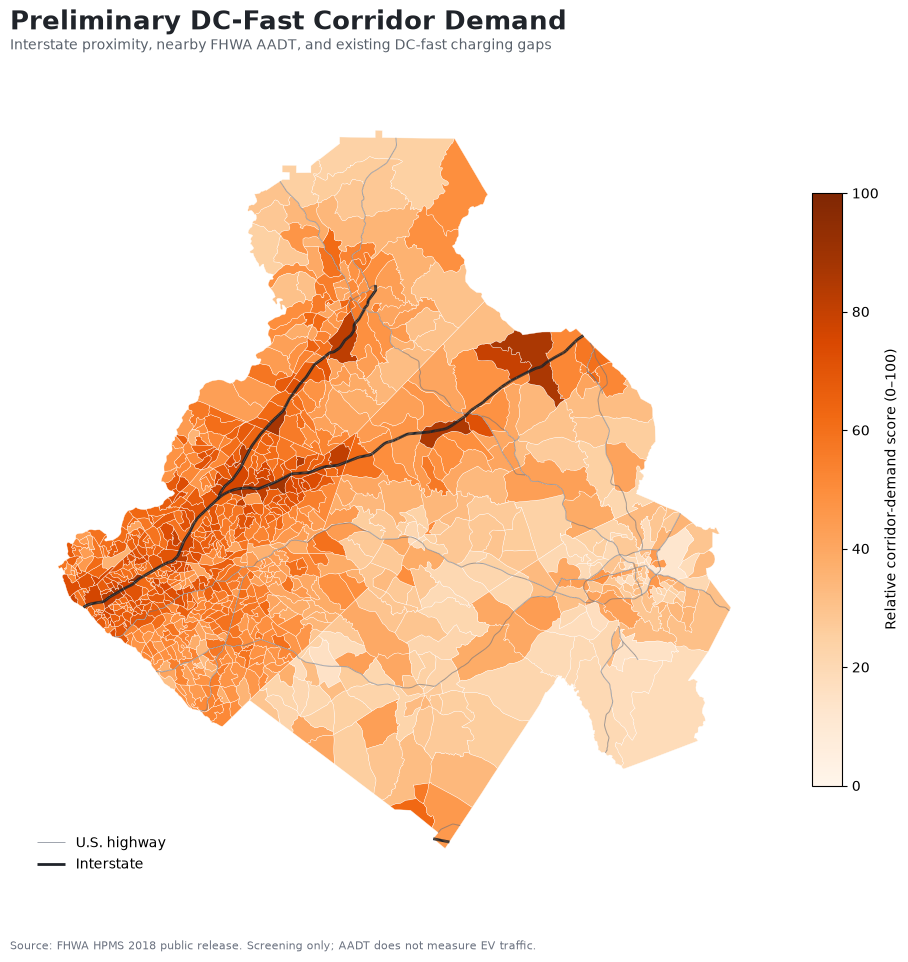

Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\maps\preliminary_dc_fast_corridor_demand.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 10), facecolor="white")
corridor.to_crs("EPSG:4326").plot(
    column="dc_corridor_score", ax=ax, cmap="Oranges", vmin=0, vmax=100,
    edgecolor="white", linewidth=0.25, legend=True,
    legend_kwds={"label": "Relative corridor-demand score (0–100)", "shrink": 0.75},
)
us_highways.plot(ax=ax, color="#6B7280", linewidth=0.7, alpha=0.65, label="U.S. highway")
interstates.plot(ax=ax, color="#20242A", linewidth=2.0, label="Interstate")

fig.suptitle("Preliminary DC-Fast Corridor Demand", x=0.04, y=0.965, ha="left", fontsize=19, weight="bold", color="#20242A")
fig.text(0.04, 0.925, "Interstate proximity, nearby FHWA AADT, and existing DC-fast charging gaps", ha="left", fontsize=10, color="#59616B")
ax.legend(frameon=False, loc="lower left")
ax.set_axis_off()
fig.text(0.04, 0.025, "Source: FHWA HPMS 2018 public release. Screening only; AADT does not measure EV traffic.", fontsize=8, color="#6B7280")
fig.subplots_adjust(left=0.03, right=0.90, top=0.88, bottom=0.09)

map_path = MAP_DIR / "preliminary_dc_fast_corridor_demand.png"
fig.savefig(map_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", map_path)

## Validation

In [7]:
assert corridor["GEOID"].is_unique
assert len(corridor) == len(gap), "The nearest-feature joins changed block-group grain."
assert corridor[["interstate_distance_miles", "aadt_value", "dc_corridor_score"]].notna().all().all()
assert (corridor["interstate_distance_miles"] >= 0).all()
assert (corridor["aadt_value"] > 0).all()
assert corridor["dc_corridor_score"].between(0, 100).all()

expected_outputs = [
    SPATIAL_DIR / "dc_fast_corridor_demand.gpkg",
    TABLE_DIR / "dc_fast_corridor_ranking.csv",
    MAP_DIR / "preliminary_dc_fast_corridor_demand.png",
]
assert all(path.exists() for path in expected_outputs)

print("All source, grain, distance, score, and output checks passed.")
assert hpms["year_record"].dropna().eq(2018).all()
print("Validation status: Share with caveats—the HPMS traffic vintage is 2018 and must be refreshed before investment decisions.")

All source, grain, distance, score, and output checks passed.
Validation status: Share with caveats—the HPMS traffic vintage is 2018 and must be refreshed before investment decisions.


## Next Steps

Add destination features and feasible developed land for the Level 2 model, then screen environmental exclusions and candidate parcels.